<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/MystockChecker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter stock ticker (example: SNDK): Futu

FUTU — Yahoo Finance six-month analysis
-------------------------------------------------------
Latest close:          $109.02
20-day average:        $102.46
50-day average:        $99.26
100-day average:       $121.44
Relative volume:       0.35x
60-day price range:    $89.76 to $142.74
Last 25 trading days:  0 accumulation, 0 distribution

Likely stage: Stage 1 — Base-building / accumulation watchlist
Decision:     WAIT

Confirmation needed: Build a stable base, then break resistance on strong volume.

Note: This infers institutional activity from price and volume.
It is educational analysis, not financial advice.


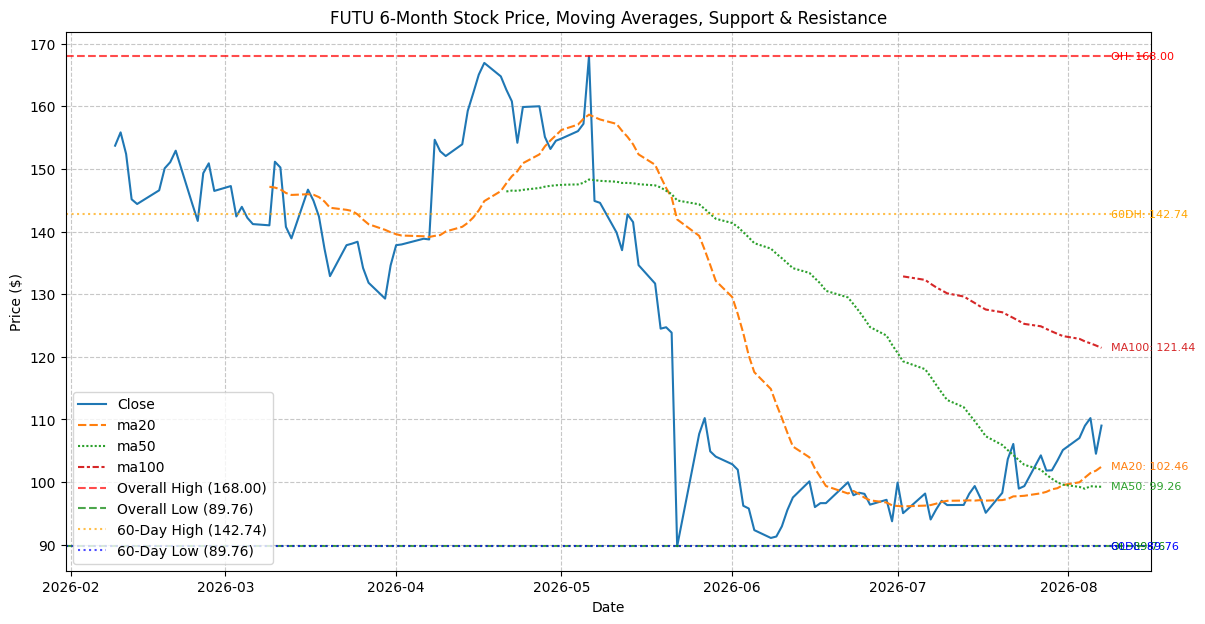

In [ ]:
# stock_stage.py
# Install once: pip install yfinance pandas

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TICKER = input("Enter stock ticker (example: SNDK): ").strip().upper()

if not TICKER:
    raise SystemExit("Ticker cannot be blank.")

# Download six months of daily Yahoo Finance OHLCV data
df = yf.download(
    TICKER,
    period="6mo",
    interval="1d",
    auto_adjust=True,
    progress=False,
)

if df.empty or len(df) < 60:
    raise SystemExit(f"Not enough Yahoo Finance data found for {TICKER}.")

# Handle yfinance versions that return multi-level column names
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

close = df["Close"]
volume = df["Volume"]

# Moving averages and relative volume
df["ma20"] = close.rolling(20).mean()
df["ma50"] = close.rolling(50).mean()
df["ma100"] = close.rolling(100).mean()
df["vol50"] = volume.rolling(50).mean()
df["pct_change"] = close.pct_change()

# Price-volume activity inference:
# Accumulation = up day with above-average volume
# Distribution = down day with above-average volume
df["accumulation_day"] = (
    (df["pct_change"] > 0.002) &
    (volume > df["vol50"])
)

df["distribution_day"] = (
    (df["pct_change"] < -0.002) &
    (volume > df["vol50"])
)

last = df.iloc[-1]
recent = df.tail(25)

price = float(last["Close"])
ma20 = float(last["ma20"])
ma50 = float(last["ma50"])
ma100 = float(last["ma100"])

rvol = float(last["Volume"] / last["vol50"])
acc_days = int(recent["accumulation_day"].sum())
dist_days = int(recent["distribution_day"].sum())

high_60 = float(close.tail(60).max())
low_60 = float(close.tail(60).min())
near_60_day_high = price >= high_60 * 0.97
near_60_day_low = price <= low_60 * 1.05

# Direction of the 50-day moving average over the latest 10 sessions
ma50_slope = float(df["ma50"].iloc[-1] / df["ma50"].iloc[-11] - 1)

# Six-month price-volume stage classification
if price < ma50 and price < ma100 and ma50_slope < 0:
    stage = "Stage 4 — Markdown / institutional selling risk"
    verdict = "AVOID"

elif (
    price > ma50
    and price > ma100
    and ma50_slope > 0
    and near_60_day_high
):
    stage = "Stage 2 — Markup / advancing trend"
    verdict = "BUY" if rvol >= 1.20 and dist_days <= 4 else "WAIT"

elif price < ma20 and dist_days > acc_days and (
    near_60_day_high or ma50_slope <= 0
):
    stage = "Stage 3 — Distribution / topping risk"
    verdict = "WAIT"

else:
    stage = "Stage 1 — Base-building / accumulation watchlist"
    verdict = "WAIT"

print(f"\n{TICKER} — Yahoo Finance six-month analysis")
print("-" * 55)
print(f"Latest close:          ${price:,.2f}")
print(f"20-day average:        ${ma20:,.2f}")
print(f"50-day average:        ${ma50:,.2f}")
print(f"100-day average:       ${ma100:,.2f}")
print(f"Relative volume:       {rvol:.2f}x")
print(f"60-day price range:    ${low_60:,.2f} to ${high_60:,.2f}")
print(f"Last 25 trading days:  {acc_days} accumulation, {dist_days} distribution")
print(f"\nLikely stage: {stage}")
print(f"Decision:     {verdict}")

if verdict == "BUY":
    print("\nConfirmation: Uptrend and near-breakout behavior detected.")
    print("Risk control: Use a position size and stop-loss you can afford.")

elif verdict == "WAIT":
    print("\nConfirmation needed: Build a stable base, then break resistance on strong volume.")

else:
    print("\nAvoid new buying until price recovers above rising moving averages")
    print("and shows sustained accumulation.")

print("\nNote: This infers institutional activity from price and volume.")
print("It is educational analysis, not financial advice.")

# Visualization
plt.figure(figsize=(14, 7))
lines = sns.lineplot(data=df[['Close', 'ma20', 'ma50', 'ma100']])
plt.title(f'{TICKER} 6-Month Stock Price, Moving Averages, Support & Resistance')
plt.xlabel('Date')
plt.ylabel('Price ($)')

# Get existing handles and labels from sns.lineplot
handles, labels = lines.get_legend_handles_labels()

# Add historical high and low as support/resistance
overall_high = df['Close'].max()
overall_low = df['Close'].min()

line_overall_high = plt.axhline(overall_high, color='red', linestyle='--', alpha=0.7, label=f'Overall High ({overall_high:,.2f})')
line_overall_low = plt.axhline(overall_low, color='green', linestyle='--', alpha=0.7, label=f'Overall Low ({overall_low:,.2f})')
line_60_high = plt.axhline(high_60, color='orange', linestyle=':', alpha=0.7, label=f'60-Day High ({high_60:,.2f})')
line_60_low = plt.axhline(low_60, color='blue', linestyle=':', alpha=0.7, label=f'60-Day Low ({low_60:,.2f})')

# Add text annotations for values
last_date = df.index[-1]
# Adjust x-offset for text to be slightly outside the plot area or on the right edge
# We'll use a numerical offset after converting date to matplotlib number
x_offset_val = plt.gca().get_xlim()[1] # get rightmost x-limit

# Calculate a slight offset from the last date for text placement
# Using a proportion of the x-axis range for consistent spacing
x_range = (df.index.max() - df.index.min()).days
x_text_pos = df.index.max() + pd.Timedelta(days=x_range * 0.01) # 1% of total range

# Moving Averages (matching sns.lineplot default colors for ma20, ma50, ma100)
plt.text(x_text_pos, df['ma20'].iloc[-1], f'MA20: {ma20:,.2f}', fontsize=8, color=handles[1].get_color(), ha='left', va='center')
plt.text(x_text_pos, df['ma50'].iloc[-1], f'MA50: {ma50:,.2f}', fontsize=8, color=handles[2].get_color(), ha='left', va='center')
plt.text(x_text_pos, df['ma100'].iloc[-1], f'MA100: {ma100:,.2f}', fontsize=8, color=handles[3].get_color(), ha='left', va='center')

# Support and Resistance
plt.text(x_text_pos, overall_high, f'OH: {overall_high:,.2f}', fontsize=8, color='red', ha='left', va='center')
plt.text(x_text_pos, overall_low, f'OL: {overall_low:,.2f}', fontsize=8, color='green', ha='left', va='center')
plt.text(x_text_pos, high_60, f'60DH: {high_60:,.2f}', fontsize=8, color='orange', ha='left', va='center')
plt.text(x_text_pos, low_60, f'60DL: {low_60:,.2f}', fontsize=8, color='blue', ha='left', va='center')

handles.extend([line_overall_high, line_overall_low, line_60_high, line_60_low])
labels.extend([
    f'Overall High ({overall_high:,.2f})',
    f'Overall Low ({overall_low:,.2f})',
    f'60-Day High ({high_60:,.2f})',
    f'60-Day Low ({low_60:,.2f})'
])

plt.legend(handles=handles, labels=labels)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

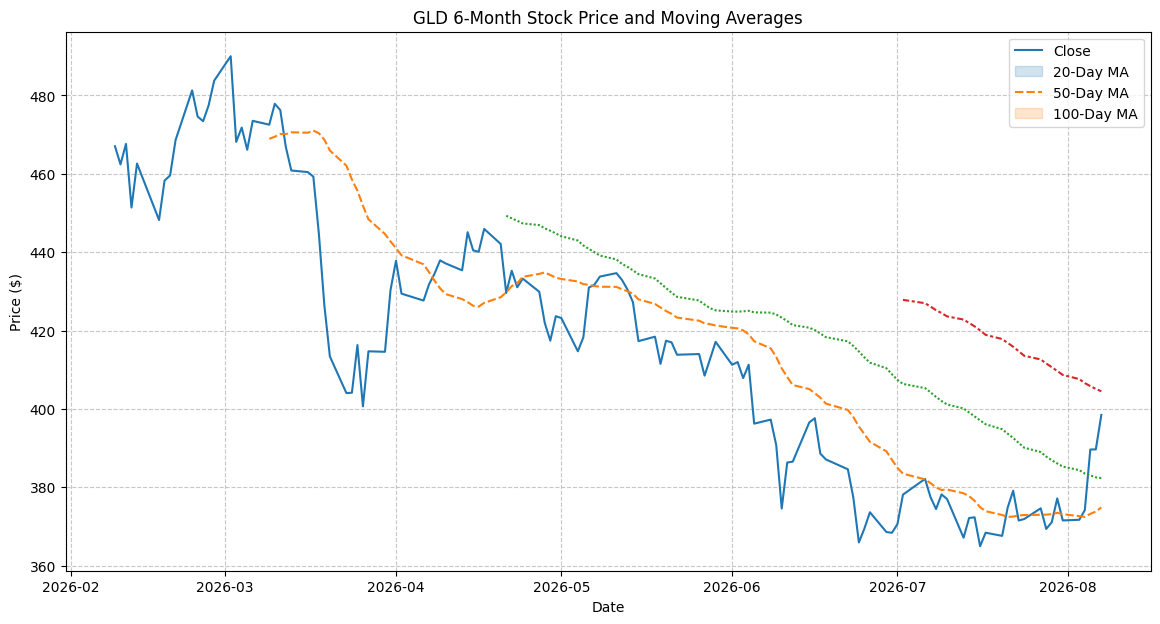

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=df[['Close', 'ma20', 'ma50', 'ma100']])
plt.title(f'{TICKER} 6-Month Stock Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(['Close', '20-Day MA', '50-Day MA', '100-Day MA'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()